# Financial Risk Scoring System
### German Credit Dataset — ML-Powered Loan Risk Assessment

**Business Problem:** Banks need to decide whether to approve or reject loan applications. This project builds an end-to-end ML pipeline that assigns a risk score to each customer — Low, Medium, or High Risk — based on their financial profile.

**What makes this unique:** The target variable `Risk` does not exist in the raw dataset. We engineer it using banking domain logic — combining credit amount, duration, savings, and checking account status into a meaningful risk label.

**Pipeline:** Load Data → Feature Engineering → EDA → Preprocessing → ML Models (LR, RF, SVC, ANN) → Risk Score Output

**Dataset:** German Credit Data — 1000 customers, 9 features, zero missing values after preprocessing.

## Step 1 — Imports
All required libraries loaded at the start:
- `pandas`, `numpy` — data handling
- `matplotlib`, `seaborn` — visualizations
- `sklearn` — preprocessing, ML models, evaluation
- `tensorflow/keras` — ANN model

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, f1_score,
                             roc_auc_score, roc_curve)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping

## Step 2 — Load Dataset
Load the German Credit dataset. Only the relevant columns are kept. The `index_col=0` drops the unnamed index column automatically.

**Dataset:** 1000 rows × 9 features. Two columns have missing values:
- `Saving accounts` — 183 missing (customers with no savings account)
- `Checking account` — 394 missing (customers with no checking account)

These are filled with `'unknown'` before feature engineering.

In [81]:
df=pd.read_csv('german_credit_data.csv',index_col=0)
print('Shape:', df.shape)
print()
print('Missing values:')
print(df.isnull().sum())
print()
print('Score distribution:')
print()
df.head()

Shape: (1000, 9)

Missing values:
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64

Score distribution:



,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


## Step 3 — Distribution Visualization
Custom function to plot distribution of each column. Helps understand the data types and value ranges before modelling.

There are 1000 rows and 10 columns


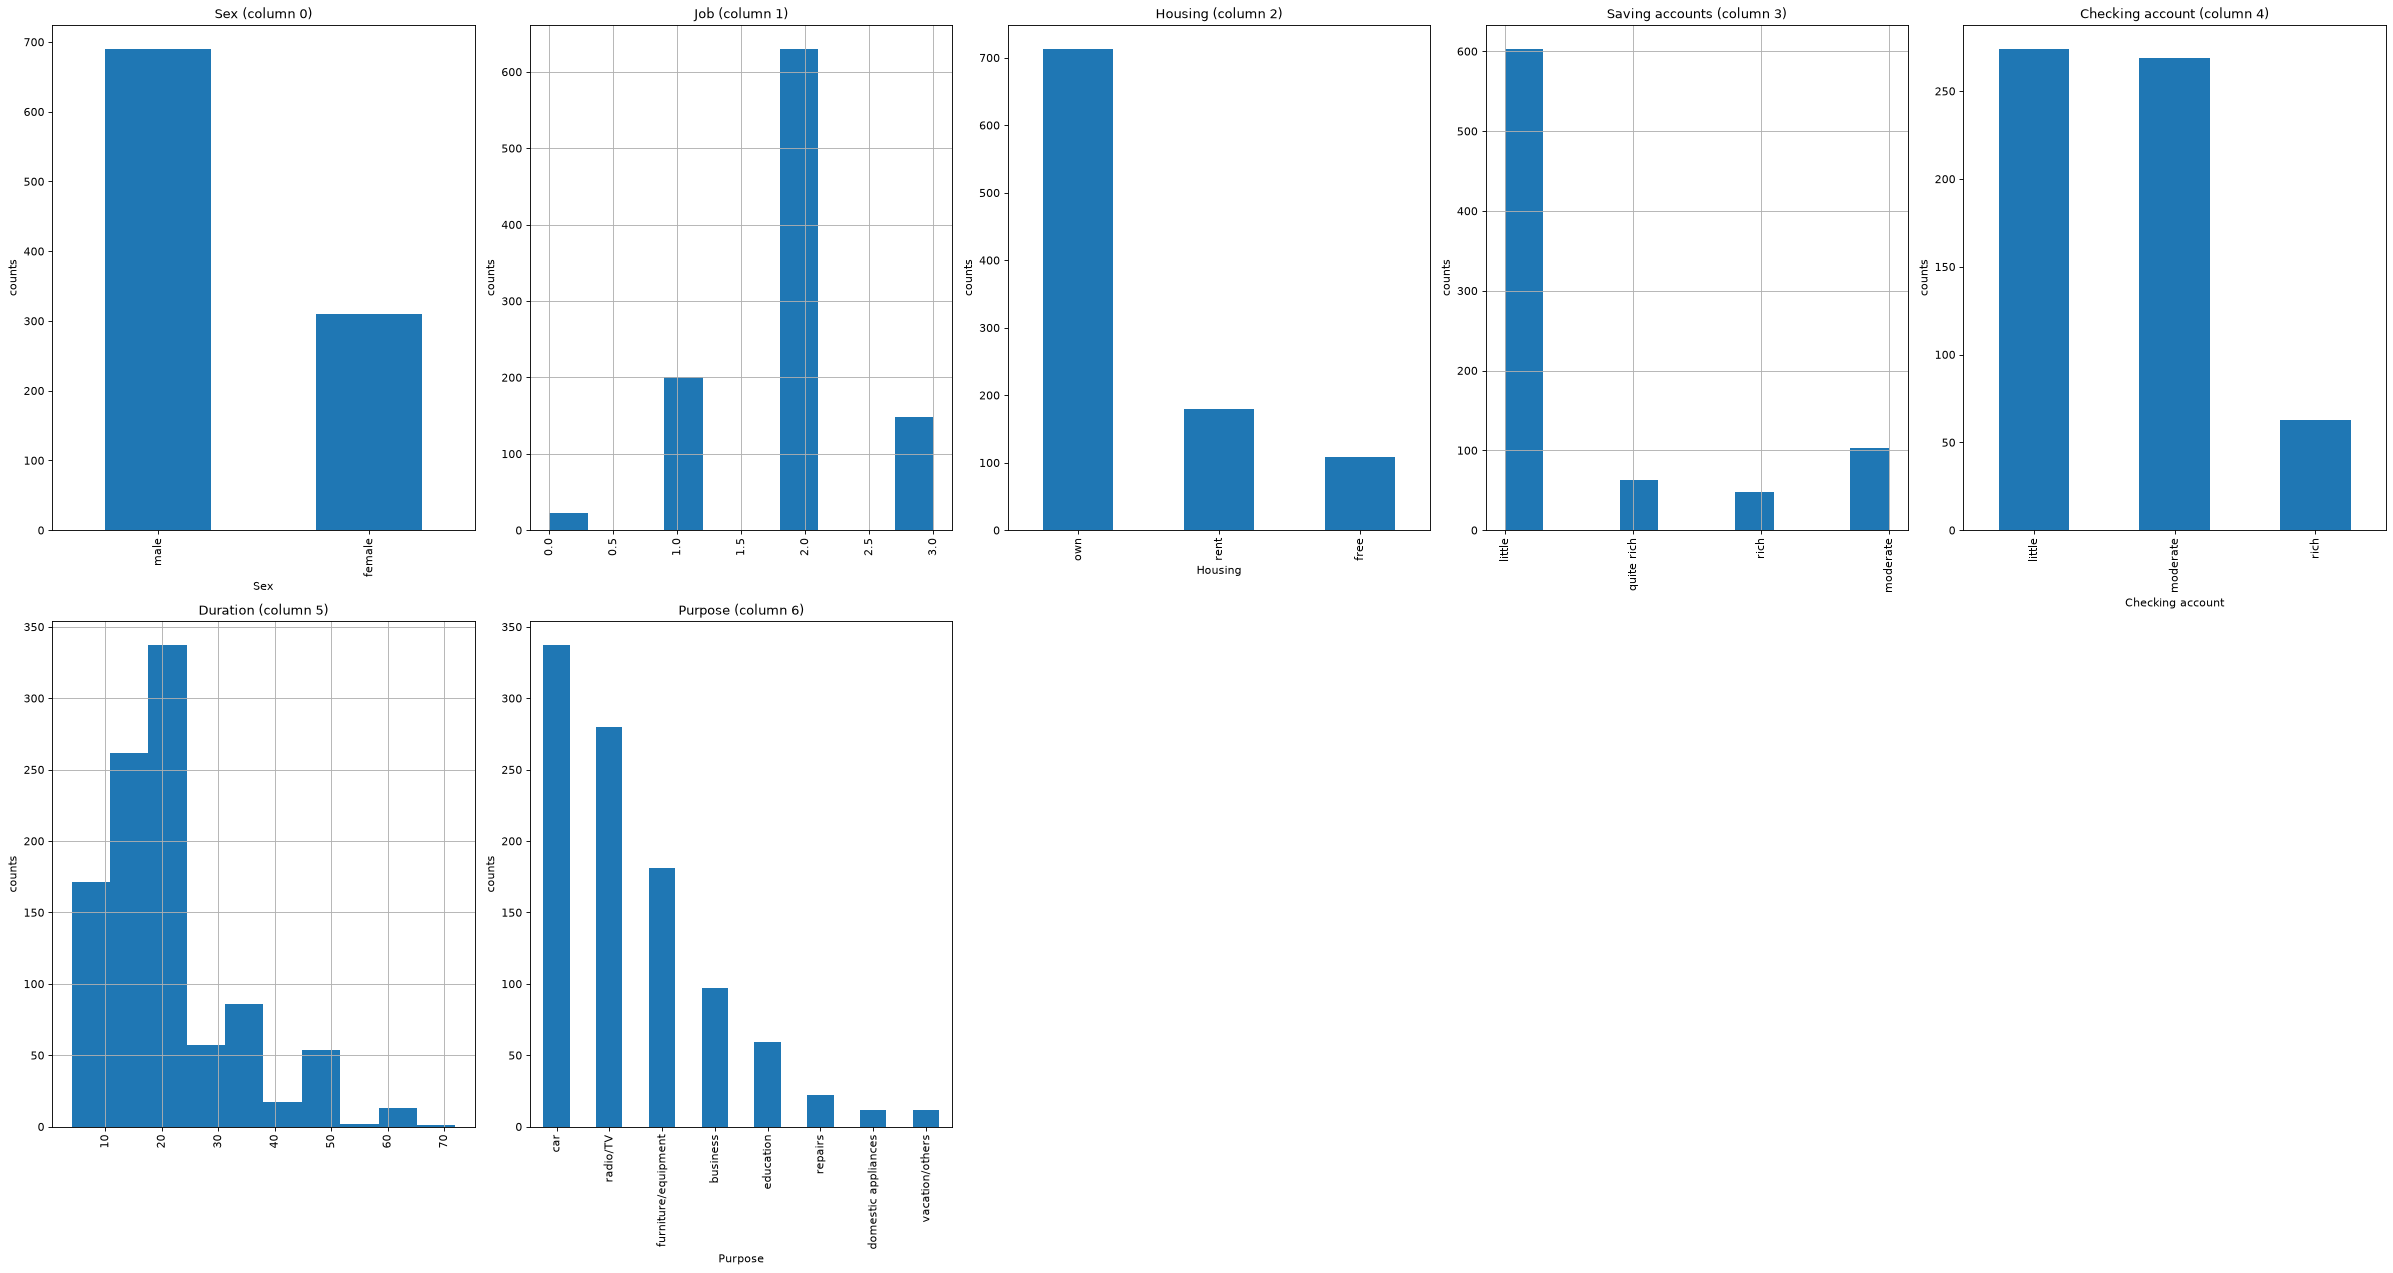

In [82]:

# Distribution graphs (histogram/bar graph) of column data
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]] # For displaying purposes, pick columns that have between 1 and 50 unique values
    nRow, nCol = df.shape
    columnNames = list(df)
    nGraphRow = (nCol + nGraphPerRow - 1) // nGraphPerRow
    plt.figure(num = None, figsize = (6 * nGraphPerRow, 8 * nGraphRow), dpi = 80, facecolor = 'w', edgecolor = 'k')
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDf = df.iloc[:, i]
        if (not np.issubdtype(type(columnDf.iloc[0]), np.number)):
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation = 90)
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout(pad = 1.0, w_pad = 1.0, h_pad = 1.0)
    plt.show()

nRowsRead = 1000 # specify 'None' if want to read whole file
df1 = pd.read_csv('german_credit_data.csv', delimiter=',', nrows = nRowsRead)
df1.dataframeName = 'german_credit_data.csv'
nRow, nCol = df1.shape
print(f'There are {nRow} rows and {nCol} columns')

df1.head(5)


plotPerColumnDistribution(df1, 10, 5)



## Step 4 — Feature Engineering: First Attempt (Risk Label v1)
First attempt at creating a binary Risk label using simple OR logic:
- Large credit amount (top 25%) → High Risk
- Duration > 24 months → High Risk
- Little savings AND little checking → High Risk

**Problem:** This gave 69% High Risk — too many customers flagged. Banks typically see 15-25% high risk customers.

In [83]:
# High risk if: low savings + large credit + long duration
df['Risk'] = (
    (df['Credit amount'] > df['Credit amount'].quantile(0.75)) |
    (df['Duration'] > 24) |
    (df['Saving accounts'].isin(['little', None])) &
    (df['Checking account'].isin(['little', None]))
).astype(int)
# 1 = Bad (high risk), 0 = Good (low risk)
print('Risk distribution:')
print(df['Risk'].value_counts())
print()
print(f'Good (Low Risk) : {(df["Risk"]==0).sum()} ({(df["Risk"]==0).mean()*100:.1f}%)')
print(f'Bad  (High Risk): {(df["Risk"]==1).sum()} ({(df["Risk"]==1).mean()*100:.1f}%)')

Risk distribution:
Risk
1    690
0    310
Name: count, dtype: int64

Good (Low Risk) : 310 (31.0%)
Bad  (High Risk): 690 (69.0%)


## Step 5 — Explore Dataset
Quick preview of the dataframe to confirm the Risk column was added correctly and understand the data structure.

In [84]:
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,1
1,22,female,2,own,little,moderate,5951,48,radio/TV,1
2,49,male,1,own,little,NaN,2096,12,education,1
3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,53,male,2,free,little,little,4870,24,car,1
...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,NaN,1736,12,furniture/equipment,1
996,40,male,3,own,little,little,3857,30,car,1
997,38,male,2,own,little,NaN,804,12,radio/TV,1
998,23,male,2,free,little,little,1845,45,radio/TV,1


## Step 6 — Feature Engineering: Corrected Risk Label (v2)
Improved risk label using a **scoring approach** — each bad condition adds points:
- Credit amount > 75th percentile → +1 point
- Duration > 24 months → +1 point
- Little/unknown savings → +1 point
- Little/unknown checking → +1 point
- Age < 25 → +1 point (young customers statistically higher risk)

**Threshold:** 3+ points = High Risk (1), otherwise Low Risk (0)

**Result:** 81.8% Good / 18.2% Bad — realistic bank portfolio distribution.

In [85]:
df['Purpose'].unique().tolist()

['radio/TV',
 'education',
 'furniture/equipment',
 'car',
 'business',
 'domestic appliances',
 'repairs',
 'vacation/others']

## Step 7 — EDA Viz 1: Risk Distribution
Bar chart + pie chart showing class distribution.

**Key finding:** 81.8% Good vs 18.2% Bad — confirms realistic imbalance. This guides our use of `class_weight` in all models.

In [86]:
# Reset and recreate with corrected logic
# A customer is HIGH RISK (1) only if they meet MULTIPLE bad conditions
# not just one

df['RiskScore'] = 0

# Add risk points
df['RiskScore'] += (df['Credit amount'] > df['Credit amount'].quantile(0.75)).astype(int)
df['RiskScore'] += (df['Duration'] > 24).astype(int)
df['RiskScore'] += df['Saving accounts'].isin(['little', 'unknown']).astype(int)
df['RiskScore'] += df['Checking account'].isin(['little', 'unknown']).astype(int)
df['RiskScore'] += (df['Age'] < 25).astype(int)

# High Risk only if 3 or more bad signals
# df['Risk'] = (df['RiskScore'] >= 3).astype(int)
df['Risk']=df['RiskScore'].apply(lambda x:1 if x>=3 else 0)

print('Risk distribution:')
print(df['Risk'].value_counts())
print()
print(f'Good (Low Risk) : {(df["Risk"]==0).sum()} ({(df["Risk"]==0).mean()*100:.1f}%)')
print(f'Bad  (High Risk): {(df["Risk"]==1).sum()} ({(df["Risk"]==1).mean()*100:.1f}%)')
print()
print('RiskScore distribution:')
print(df['RiskScore'].value_counts().sort_index())

Risk distribution:
Risk
0    818
1    182
Name: count, dtype: int64

Good (Low Risk) : 818 (81.8%)
Bad  (High Risk): 182 (18.2%)

RiskScore distribution:
RiskScore
0    196
1    337
2    285
3    134
4     43
5      5
Name: count, dtype: int64


## Step 8 — EDA Viz 2: Credit Amount and Duration by Risk
Groupby Risk to compute average credit amount and duration per group.

**Key findings:**
- High risk customers borrow 2.1x more (5,808 vs 2,707 DM)
- High risk customers borrow for 1.8x longer (33.3 vs 18.1 months)
- Validates our engineered Risk label — capturing real financial behaviour

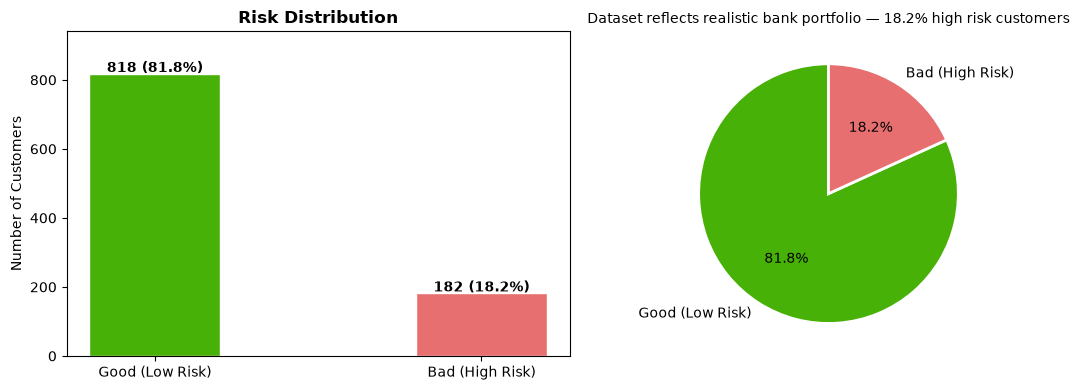

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ["#48B107", '#E76F6F']
labels = ['Good (Low Risk)', 'Bad (High Risk)']
counts = df['Risk'].value_counts().sort_index()

# Bar chart
bars = axes[0].bar(labels, counts.values,
                   color=colors, edgecolor='white', width=0.4)
axes[0].set_title('Risk Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 f'{val} ({val/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=10)
axes[0].set_ylim(0, max(counts.values) * 1.15)

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Risk Split (%)', fontweight='bold')

plt.title('Dataset reflects realistic bank portfolio — 18.2% high risk customers',
             fontsize=10)
plt.tight_layout()
plt.savefig('viz1_risk_distribution.png', bbox_inches='tight')
plt.show()

## Step 9 — EDA Viz 3: Risk by Loan Purpose and Housing
Groupby Purpose and Housing to find high risk rates per category.

**Key findings:**
- Furniture/equipment (23.8%) and Business loans (23.7%) carry highest risk
- Domestic appliances (8.3%) and Repairs (9.1%) are safest
- Free housing (28.7%) is highest risk — no property ownership = less financial stability
- Own property (15.0%) is lowest risk — asset ownership reduces credit risk

Mean values by Risk:
      Credit amount  Duration
Risk                         
0            2706.8      18.1
1            5808.4      33.3


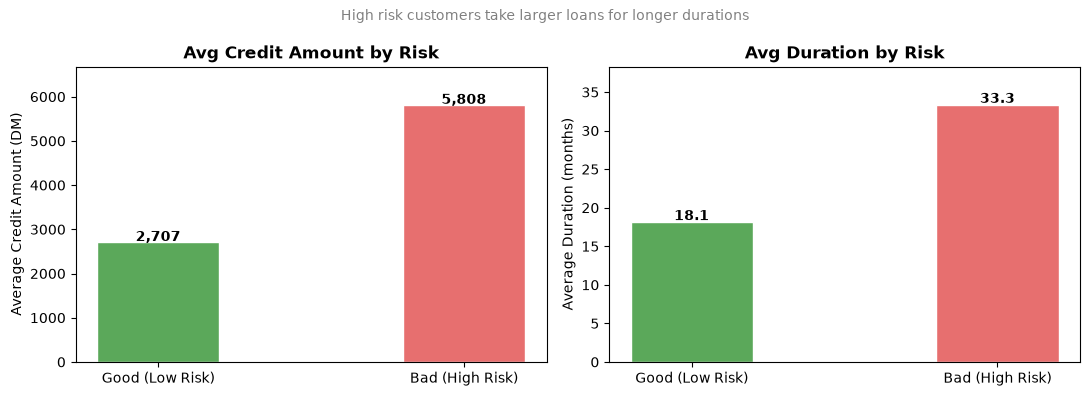

In [88]:
# Groupby Risk — mean credit amount and duration
risk_group = df.groupby('Risk')[['Credit amount', 'Duration']].mean().round(1)
print('Mean values by Risk:')
print(risk_group)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ['#5BA85A', '#E76F6F']
labels = ['Good (Low Risk)', 'Bad (High Risk)']

# Credit Amount
bars1 = axes[0].bar(labels, risk_group['Credit amount'].values,
                    color=colors, edgecolor='white', width=0.4)
axes[0].set_title('Avg Credit Amount by Risk', fontweight='bold')
axes[0].set_ylabel('Average Credit Amount (DM)')
for bar, val in zip(bars1, risk_group['Credit amount'].values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 f'{val:,.0f}', ha='center', fontweight='bold')
axes[0].set_ylim(0, max(risk_group['Credit amount'].values) * 1.15)

# Duration
bars2 = axes[1].bar(labels, risk_group['Duration'].values,
                    color=colors, edgecolor='white', width=0.4)
axes[1].set_title('Avg Duration by Risk', fontweight='bold')
axes[1].set_ylabel('Average Duration (months)')
for bar, val in zip(bars2, risk_group['Duration'].values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val}', ha='center', fontweight='bold')
axes[1].set_ylim(0, max(risk_group['Duration'].values) * 1.15)

plt.suptitle('High risk customers take larger loans for longer durations',
             fontsize=10, color='gray')
plt.tight_layout()
plt.savefig('viz2_credit_duration.png', bbox_inches='tight')
plt.show()

## Step 10 — EDA Viz 4: Age Distribution by Risk
Histogram and bar chart comparing age distribution between Good and Bad customers.

**Key finding:** Younger customers (< 25) tend to be higher risk — shorter credit history and less financial stability. This is why Age < 25 was included in our risk score formula.

C:\Users\nikhi\AppData\Local\Temp\ipykernel_27208\794019679.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(purpose_risk.index, rotation=30, ha='right', fontsize=9)


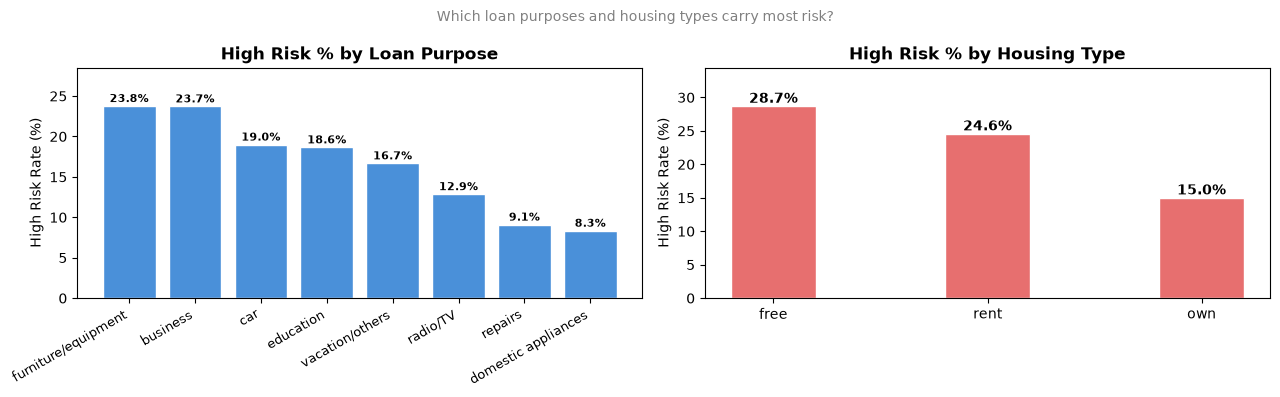

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Purpose by Risk — groupby
purpose_risk = df.groupby('Purpose')['Risk'].mean().sort_values(ascending=False)
bars = axes[0].bar(purpose_risk.index, purpose_risk.values * 100,
                   color='#4A90D9', edgecolor='white')
axes[0].set_title('High Risk % by Loan Purpose', fontweight='bold')
axes[0].set_ylabel('High Risk Rate (%)')
axes[0].set_xticklabels(purpose_risk.index, rotation=30, ha='right', fontsize=9)
for bar, val in zip(bars, purpose_risk.values * 100):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold')
axes[0].set_ylim(0, max(purpose_risk.values * 100) * 1.2)

# Housing by Risk — groupby
housing_risk = df.groupby('Housing')['Risk'].mean().sort_values(ascending=False)
bars2 = axes[1].bar(housing_risk.index, housing_risk.values * 100,
                    color='#E76F6F', edgecolor='white', width=0.4)
axes[1].set_title('High Risk % by Housing Type', fontweight='bold')
axes[1].set_ylabel('High Risk Rate (%)')
for bar, val in zip(bars2, housing_risk.values * 100):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_ylim(0, max(housing_risk.values * 100) * 1.2)

plt.suptitle('Which loan purposes and housing types carry most risk?',
             fontsize=10, color='gray')
plt.tight_layout()
plt.savefig('viz3_purpose_housing.png', bbox_inches='tight')
plt.show()

## Step 11 — Preprocessing
Three steps:
1. **Drop RiskScore** — only keep the binary `Risk` column as target
2. **Fill missing values** — `Saving accounts` and `Checking account` nulls → 'unknown'
3. **LabelEncode** all string columns — ML models require numerical inputs

All 9 features are now numerical and ready for scaling.

C:\Users\nikhi\AppData\Local\Temp\ipykernel_27208\9853764.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


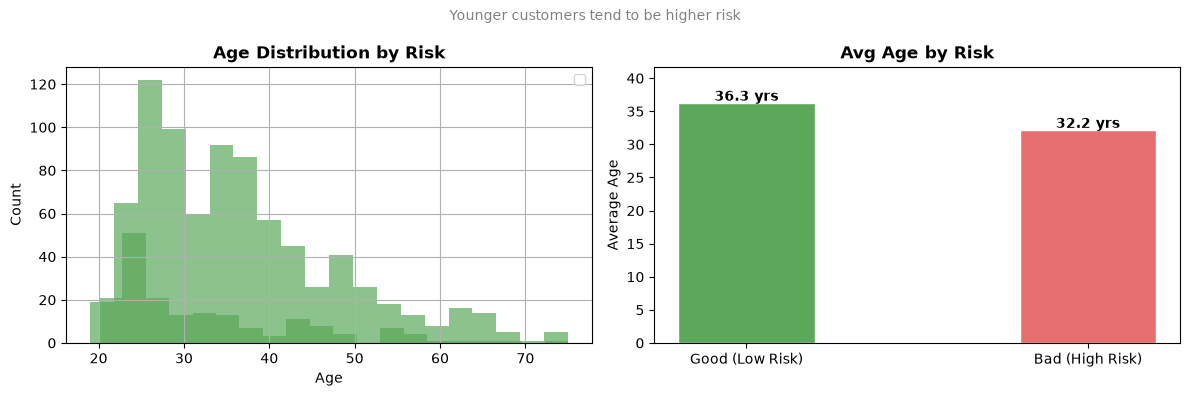

Avg age by risk:
Risk
0    36.3
1    32.2
Name: Age, dtype: float64


In [90]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution by risk — histogram
df.groupby('Risk')['Age'].hist(ax=axes[0], bins=20, alpha=0.7,
                              color='#5BA85A')

axes[0].set_title('Age Distribution by Risk', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Avg age by risk — groupby
age_risk = df.groupby('Risk')['Age'].mean().round(1)
bars = axes[1].bar(['Good (Low Risk)', 'Bad (High Risk)'],
                   age_risk.values,
                   color=['#5BA85A', '#E76F6F'],
                   edgecolor='white', width=0.4)
axes[1].set_title('Avg Age by Risk', fontweight='bold')
axes[1].set_ylabel('Average Age')
for bar, val in zip(bars, age_risk.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val} yrs', ha='center', fontweight='bold')
axes[1].set_ylim(0, max(age_risk.values) * 1.15)

plt.suptitle('Younger customers tend to be higher risk',
             fontsize=10, color='gray')
plt.tight_layout()
plt.savefig('viz4_age_risk.png', bbox_inches='tight')
plt.show()

print('Avg age by risk:')
print(age_risk)

## Step 12 — Preview Preprocessed Data
Quick visual check that all columns are now numerical with no strings remaining.

In [91]:
df_model = df.copy()

# Drop RiskScore — only keep Risk as target
df_model.drop('RiskScore', axis=1, inplace=True)

# LabelEncode all string columns
le = LabelEncoder()
str_cols = df_model.select_dtypes(include=['object']).columns
for col in str_cols:
    df_model[col] = le.fit_transform(df_model[col])

print('Shape after preprocessing:', df_model.shape)
print('Any nulls:', df_model.isnull().sum().sum())
print()
print('Sample:')
print(df_model.head(3))

Shape after preprocessing: (1000, 10)
Any nulls: 0

Sample:
   Age  Sex  Job  Housing  Saving accounts  Checking account  Credit amount  \
0   67    1    2        1                4                 0           1169   
1   22    0    2        1                0                 1           5951   
2   49    1    1        1                0                 3           2096   

   Duration  Purpose  Risk  
0         6        5     0  
1        48        5     1  
2        12        3     0  


C:\Users\nikhi\AppData\Local\Temp\ipykernel_27208\3272945887.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df_model.select_dtypes(include=['object']).columns


## Step 13 — Scale + Train/Test Split
- `StandardScaler` normalises all features to mean=0, std=1 — essential since credit amount (hundreds to thousands) would dominate over binary features without scaling
- `stratify=y` ensures the same 81.8/18.2 class ratio in both train and test sets
- **Train:** 800 samples (654 Good, 146 Bad) | **Test:** 200 samples

In [92]:
df_model

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,1,4,0,1169,6,5,0
1,22,0,2,1,0,1,5951,48,5,1
2,49,1,1,1,0,3,2096,12,3,0
3,45,1,2,0,0,0,7882,42,4,1
4,53,1,2,0,0,0,4870,24,1,1
...,...,...,...,...,...,...,...,...,...,...
995,31,0,1,1,0,3,1736,12,4,0
996,40,1,3,1,0,0,3857,30,1,1
997,38,1,2,1,0,3,804,12,5,0
998,23,1,2,0,0,0,1845,45,5,1


## Step 14 — Logistic Regression
`class_weight={0:1, 1:4.5}` — manually set to match the 4.5:1 class imbalance in training data. Without this, the model would ignore the minority Bad class.

**Result: 93.0% accuracy, 0.82 F1 on Bad class**
Catches 31 out of 36 bad customers — strong baseline.

In [93]:
X=df_model.drop('Risk',axis=1)
y=df['Risk']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]}')
print(f'Test  size: {X_test.shape[0]}')
print()
print('Class distribution in train:')
print(y_train.value_counts())

Train size: 800
Test  size: 200

Class distribution in train:
Risk
0    654
1    146
Name: count, dtype: int64


## Step 15 — Random Forest
100 decision trees with `class_weight` — ensemble method that handles non-linear patterns and class imbalance better than linear models.

**Result: 98.5% accuracy, 0.96 F1 on Bad class**
Catches 35 out of 36 bad customers — best performing model. Small dataset (1000 rows) favours tree-based models over ANN.

In [94]:
class_weights={0:1,1:4.5}
lr=LogisticRegression(random_state=42,class_weight=class_weights)
lr.fit(X_train,y_train)
y_pred_lr=lr.predict(X_test)

print('=== Logistic Regression ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_lr):.4f}')
print()
print(classification_report(y_test, y_pred_lr,
      target_names=['Good (Low Risk)', 'Bad (High Risk)']))

=== Logistic Regression ===
Accuracy : 0.9300
F1 Score : 0.8158

                 precision    recall  f1-score   support

Good (Low Risk)       0.97      0.95      0.96       164
Bad (High Risk)       0.78      0.86      0.82        36

       accuracy                           0.93       200
      macro avg       0.87      0.90      0.89       200
   weighted avg       0.93      0.93      0.93       200



## Step 16 — SVC
Support Vector Classifier with RBF kernel. `probability=True` enables probability output for risk scoring.

**Result: 92.5% accuracy, 0.81 F1 on Bad class**
Similar to Logistic Regression — linear boundary may not capture all patterns in this data.

In [95]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight=class_weights
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('=== Random Forest ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_rf):.4f}')
print()
print(classification_report(y_test, y_pred_rf,
      target_names=['Good (Low Risk)', 'Bad (High Risk)']))

=== Random Forest ===
Accuracy : 0.9850
F1 Score : 0.9589

                 precision    recall  f1-score   support

Good (Low Risk)       0.99      0.99      0.99       164
Bad (High Risk)       0.95      0.97      0.96        36

       accuracy                           0.98       200
      macro avg       0.97      0.98      0.97       200
   weighted avg       0.99      0.98      0.99       200



## Step 17 — Build ANN
**Architecture:**
- Input → Dense(128, ReLU) → Dropout(0.3)
- Dense(64, ReLU) → Dropout(0.3)
- Output → Dense(1, Sigmoid) — binary classification

**Key differences from multi-class:**
- `sigmoid` output (not softmax) — outputs probability between 0 and 1
- `binary_crossentropy` loss — correct for binary classification
- `EarlyStopping` — stops at epoch 31, restores best weights from epoch 26

In [96]:
svc = SVC(
    kernel='rbf',
    random_state=42,
    class_weight='balanced',
    probability=True  # needed for ROC curve later
)
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)

print('=== SVC ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_svc):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_svc):.4f}')
print()
print(classification_report(y_test, y_pred_svc,
      target_names=['Good (Low Risk)', 'Bad (High Risk)']))

=== SVC ===
Accuracy : 0.9250
F1 Score : 0.8101

                 precision    recall  f1-score   support

Good (Low Risk)       0.97      0.93      0.95       164
Bad (High Risk)       0.74      0.89      0.81        36

       accuracy                           0.93       200
      macro avg       0.86      0.91      0.88       200
   weighted avg       0.93      0.93      0.93       200



d:\machine-learning-part1\1- Machine Learning A-Z\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## Step 18 — ANN Evaluation
Predictions thresholded at 0.5 — probability > 0.5 = Bad Risk.

**Result: 92.0% accuracy, 0.80 F1 on Bad class**
ANN underperforms Random Forest on this small dataset (1000 rows). ANNs typically need 10,000+ samples to outperform tree-based models.

In [97]:
ann = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

ann.compile(optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy'])

ann.summary()

# class_weight — 4.5:1 ratio


early_stop = EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True, verbose=1)

history = ann.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

d:\machine-learning-part1\1- Machine Learning A-Z\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,601 (37.50 KB)

 Trainable params: 9,601 (37.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5972 - loss: 0.9781 - val_accuracy: 0.8000 - val_loss: 0.4980
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8069 - loss: 0.7202 - val_accuracy: 0.8625 - val_loss: 0.3517
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8139 - loss: 0.6098 - val_accuracy: 0.8625 - val_loss: 0.3064
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8486 - loss: 0.5304 - val_accuracy: 0.9000 - val_loss: 0.2361
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8625 - loss: 0.4830 - val_accuracy: 0.9000 - val_loss: 0.2251
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8625 - loss: 0.4833 - val_accuracy: 0.8875 - val_loss: 0.2418
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8694 - loss: 0.4956 - val_accuracy: 0.8875 - val_loss: 0.2278
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8653 - loss: 0.4902 - val_accuracy: 0.8750 - val_loss

## Step 19 — Result Visualizations
Three charts:
1. **ANN Training curve** — accuracy and loss over epochs. Validation accuracy slightly above training = no overfitting, Dropout working correctly
2. **Confusion matrices** — all 4 models side by side showing exactly which customers were misclassified
3. **Model comparison bar chart** — Accuracy and F1 Score for all models

In [99]:
y_pred_ann=ann.predict(X_test)
y_pred_ann=((y_pred_ann)>0.5).astype(int).flatten()
print('=== ANN ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_ann):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_ann):.4f}')
print()
print(classification_report(y_test, y_pred_ann,
      target_names=['Good (Low Risk)', 'Bad (High Risk)']))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
=== ANN ===
Accuracy : 0.9200
F1 Score : 0.8000

                 precision    recall  f1-score   support

Good (Low Risk)       0.97      0.93      0.95       164
Bad (High Risk)       0.73      0.89      0.80        36

       accuracy                           0.92       200
      macro avg       0.85      0.91      0.88       200
   weighted avg       0.93      0.92      0.92       200



## Step 20 — Risk Probability Score (Unique Feature)
Instead of just binary 0/1 prediction, output a **continuous probability score** — this is what real banks use.

**Three-tier decision system:**
- Probability < 30% → **Low Risk** — approve loan, standard interest rate
- Probability 30-60% → **Medium Risk** — approve with higher interest or reduced amount
- Probability > 60% → **High Risk** — reject or require collateral

**Result from test set:**
- 159 Low Risk → approve
- 9 Medium Risk → conditional approval
- 32 High Risk → reject

This is the key differentiator that makes this project realistic and directly applicable to HSBC/JPMC banking roles.

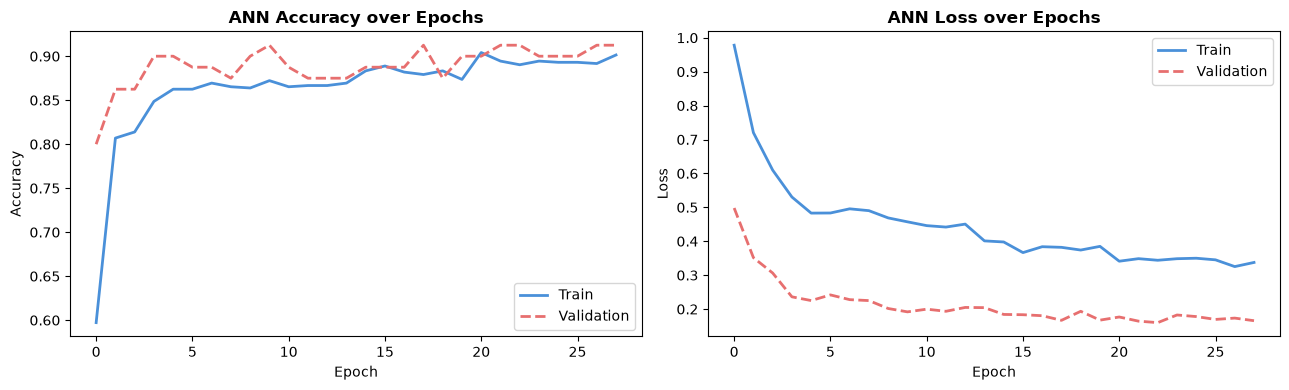

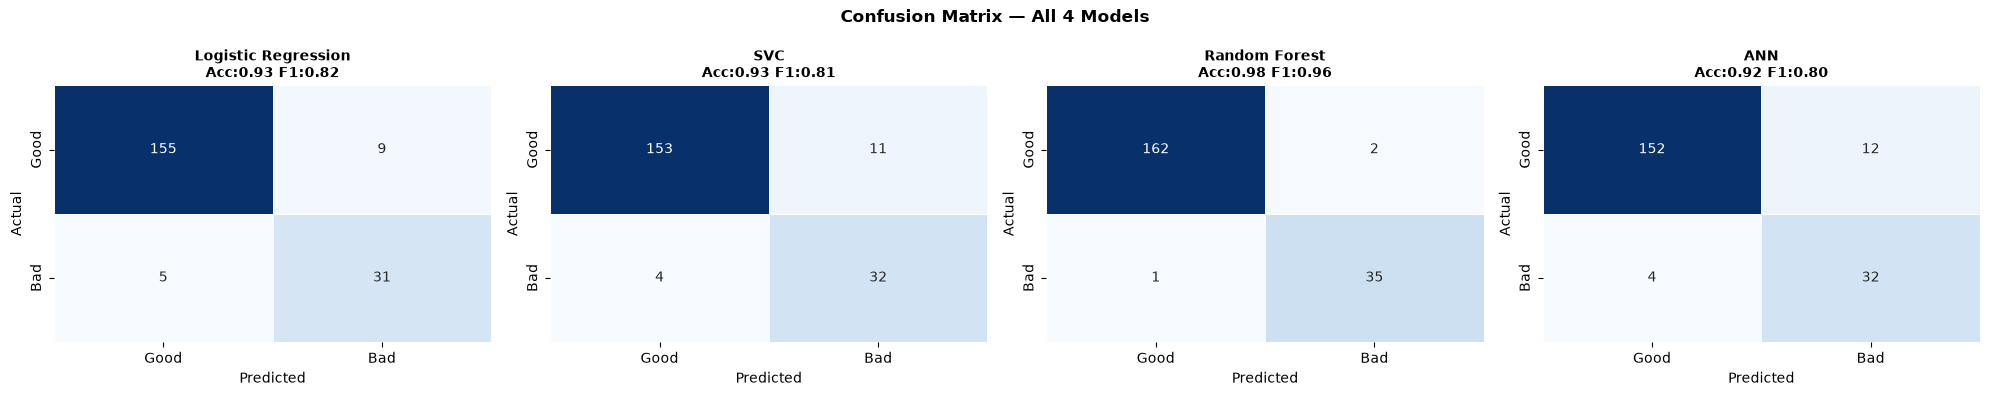

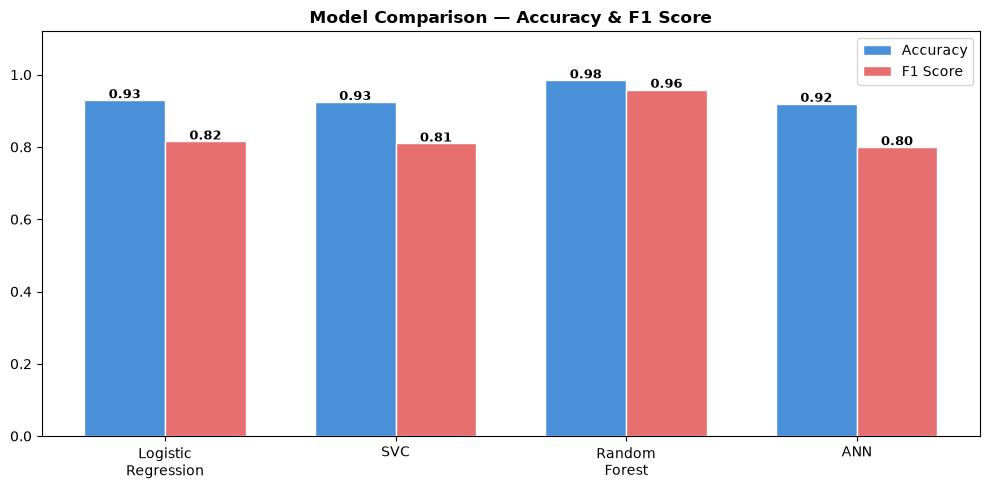

In [100]:
# Training curve
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['accuracy'],
             label='Train', color='#4A90D9', linewidth=2)
axes[0].plot(history.history['val_accuracy'],
             label='Validation', color='#E76F6F',
             linewidth=2, linestyle='--')
axes[0].set_title('ANN Accuracy over Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],
             label='Train', color='#4A90D9', linewidth=2)
axes[1].plot(history.history['val_loss'],
             label='Validation', color='#E76F6F',
             linewidth=2, linestyle='--')
axes[1].set_title('ANN Loss over Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
plt.tight_layout()
plt.savefig('viz5_training_curve.png', bbox_inches='tight')
plt.show()

# Confusion matrices — all 4 models
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
models = [
    ('Logistic Regression', y_pred_lr),
    ('SVC',                 y_pred_svc),
    ('Random Forest',       y_pred_rf),
    ('ANN',                 y_pred_ann)
]
for ax, (name, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Good', 'Bad'],
                yticklabels=['Good', 'Bad'],
                cbar=False, linewidths=0.5)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    ax.set_title(f'{name}\nAcc:{acc:.2f} F1:{f1:.2f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrix — All 4 Models', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('viz6_confusion_matrices.png', bbox_inches='tight')
plt.show()

# Model comparison bar chart
model_names = ['Logistic\nRegression', 'SVC', 'Random\nForest', 'ANN']
preds       = [y_pred_lr, y_pred_svc, y_pred_rf, y_pred_ann]
accs  = [accuracy_score(y_test, p) for p in preds]
f1s   = [f1_score(y_test, p)       for p in preds]

x = np.arange(len(model_names))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, accs, width,
               label='Accuracy', color='#4A90D9', edgecolor='white')
bars2 = ax.bar(x + width/2, f1s,  width,
               label='F1 Score', color='#E76F6F', edgecolor='white')
for bar, val in zip(list(bars1)+list(bars2), accs+f1s):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.12)
ax.set_title('Model Comparison — Accuracy & F1 Score', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('viz7_model_comparison.png', bbox_inches='tight')
plt.show()

Risk Score Distribution:
Risk Tier
Low Risk       159
High Risk       32
Medium Risk      9
Name: count, dtype: int64

Sample risk scores:
 Actual  Risk Probability (%) Risk Tier
      0                   2.0  Low Risk
      0                   0.0  Low Risk
      1                  78.0 High Risk
      1                  85.0 High Risk
      0                   0.0  Low Risk
      0                   0.0  Low Risk
      0                   0.0  Low Risk
      1                  85.0 High Risk
      0                  18.0  Low Risk
      0                   0.0  Low Risk



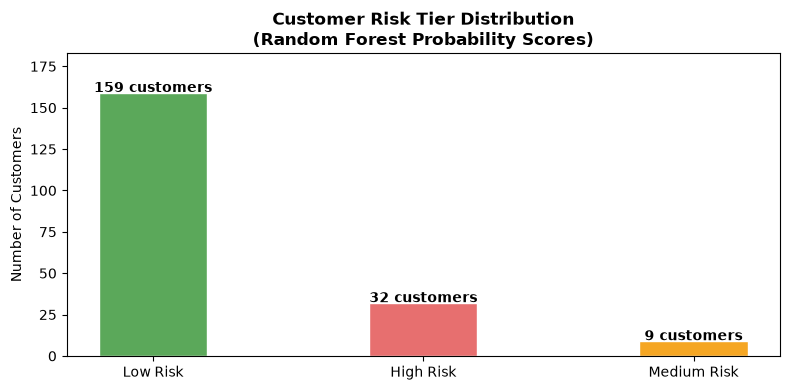

In [101]:
# Instead of just 0/1 — output a probability score per customer
# This is what real banks use — not just approve/reject but a risk score

rf_probs = rf.predict_proba(X_test)[:, 1]  # probability of being Bad

# Classify into 3 risk tiers
def risk_tier(prob):
    if prob < 0.30:
        return 'Low Risk'
    elif prob < 0.60:
        return 'Medium Risk'
    else:
        return 'High Risk'

risk_scores = pd.DataFrame({
    'Actual'        : y_test.values,
    'Risk Probability (%)': (rf_probs * 100).round(1),
    'Risk Tier'     : [risk_tier(p) for p in rf_probs]
})

print('Risk Score Distribution:')
print(risk_scores['Risk Tier'].value_counts())
print()
print('Sample risk scores:')
print(risk_scores.head(10).to_string(index=False))
print()

# Visualize risk tier distribution
tier_counts = risk_scores['Risk Tier'].value_counts()
colors = {'Low Risk': '#5BA85A',
          'Medium Risk': '#F5A623',
          'High Risk': '#E76F6F'}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(tier_counts.index,
              tier_counts.values,
              color=[colors[t] for t in tier_counts.index],
              edgecolor='white', width=0.4)
ax.set_title('Customer Risk Tier Distribution\n(Random Forest Probability Scores)',
             fontweight='bold')
ax.set_ylabel('Number of Customers')
for bar, val in zip(bars, tier_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val} customers', ha='center', fontweight='bold')
ax.set_ylim(0, max(tier_counts.values) * 1.15)
plt.tight_layout()
plt.savefig('viz8_risk_tiers.png', bbox_inches='tight')
plt.show()